In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy.optimize import minimize
from google.colab import drive
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style='whitegrid', font_scale=1.3, palette='Set2')

In [ ]:
data = pd.read_stata('Data for Group Assignment 1.dta')

In [ ]:
data.head()

,id,year,TRBCEconomicSectorName,TRBCBusinessSectorName,TRBCIndustryGroupName,female,roa,trev,cogs,gp,...,teq,marcap,emp,beta,esgs,ind,dirnetwork,age,nquals,boardsize
0,12.0,2007.0,Energy,Uranium,Uranium,0.0,-35.743146,9.820262e+05,NaN,NaN,...,1.960230e+07,7.461715e+07,20.0,NaN,NaN,0.400000,444.600000,71.000000,2.800000,5.0
1,12.0,2008.0,Energy,Uranium,Uranium,0.0,-30.299690,2.072448e+06,NaN,NaN,...,1.520079e+07,1.834640e+07,29.0,NaN,NaN,0.333333,409.666667,59.000000,2.666667,6.0
2,12.0,2009.0,Energy,Uranium,Uranium,0.0,-36.862254,4.024032e+05,NaN,NaN,...,1.566843e+07,9.226658e+07,15.0,NaN,NaN,0.285714,372.428571,60.000000,2.714286,7.0
3,12.0,2010.0,Energy,Uranium,Uranium,0.0,-54.475718,4.893411e+05,NaN,NaN,...,1.509513e+07,1.878285e+08,37.0,NaN,19.809704,0.285714,402.428571,60.333332,2.428571,7.0
4,12.0,2011.0,Energy,Uranium,Uranium,0.0,-36.467285,9.539094e+05,NaN,NaN,...,4.743890e+07,4.956273e+07,44.0,NaN,14.846020,0.166667,93.333333,56.500000,1.666667,6.0


In [ ]:
missing_data = data[data['year'] == 2010].isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("Переменные с наибольшим количеством пропусков (%):")
print(missing_data.head(10))

Переменные с наибольшим количеством пропусков (%):
beta        100.000000
rd           86.965377
esgs         84.114053
labcosts     63.136456
tinv         42.362525
intang       34.826884
gm           21.181263
capex        20.366599
ppe          19.348269
gp           16.700611
dtype: float64


Видим, что переменные rd (затраты на R&D), esgs (ESG indicator), beta (рыночная бета) имеют более 70% пропущенных значений, значит нужно аккуратнее подойти к их анализу

In [ ]:
print('Значения, которые принимает переменная TRBCEconomicSectorName (название экономического сектора компании)')
print(data['TRBCEconomicSectorName'].unique())
print('\nЗначения, которые принимает переменная TRBCBusinessSectorName (название бизнес-сектора компании)')
print(data['TRBCBusinessSectorName'].unique())
print('\nЗначения, которые принимает переменная TRBCIndustryGroupName (название индустриального сектора компании)')
print(data['TRBCIndustryGroupName'].unique())

Значения, которые принимает переменная TRBCEconomicSectorName (название экономического сектора компании)
['Energy' 'Basic Materials' 'Technology' 'Financials' 'Industrials'
 'Consumer Cyclicals' 'Consumer Non-Cyclicals' 'Healthcare' 'Utilities'
 'Telecommunications Services']

Значения, которые принимает переменная TRBCBusinessSectorName (название бизнес-сектора компании)
['Uranium' 'Mineral Resources' 'Technology Equipment'
 'Collective Investments' 'Software & IT Services'
 'Industrial & Commercial Services' 'Banking & Investment Services'
 'Transportation' 'Cyclical Consumer Products' 'Energy - Fossil Fuels'
 'Retailers' 'Real Estate' 'Food & Beverages' 'Industrial Goods'
 'Pharmaceuticals & Medical Research' 'Applied Resources' 'Chemicals'
 'Insurance' 'Automobiles & Auto Parts' 'Healthcare Services & Equipment'
 'Cyclical Consumer Services' 'Investment Holding Companies' 'Utilities'
 'Industrial Conglomerates' 'Renewable Energy'
 'Telecommunications Services' 'Personal & Household

**Возьмём treatment date - 2015 и посмотрим сколько в каждой группе  (treated (с женщинами), untreated) компаний. Также проверим что в 2010 нет treatment**

# Мой способ

Начало

In [ ]:
keep_vars = list(set(data.columns) - set(missing_data.index[:15]) - set(['id', 'female', 'year']))
keep_vars

['opin',
 'emp',
 'ind',
 'marcap',
 'roa',
 'cl',
 'age',
 'div',
 'boardsize',
 'opex',
 'TRBCBusinessSectorName',
 'ni',
 'teq',
 'TRBCEconomicSectorName',
 'stdebt',
 'TRBCIndustryGroupName',
 'dirnetwork',
 'ta',
 'nquals',
 'ltdebt',
 'tliab',
 'trev',
 'ca',
 'tdebt']

In [ ]:
data_2010 = data[data['year'] == 2010][['id'] + keep_vars].copy()
print("Оставлено переменных:", len(keep_vars))
print("Фирм в 2010:", len(data_2010))

Оставлено переменных: 24
Фирм в 2010: 491


In [ ]:
# Переменные для корреляций (исключаем категориальные отраслевые)
num_vars = [c for c in keep_vars if c not in ['TRBCEconomicSectorName', 'TRBCBusinessSectorName', 'TRBCIndustryGroupName']]

corr_data = data_2010[num_vars].dropna()
print("Наблюдений для корреляций:", len(corr_data))

corr_matrix = corr_data.corr()

print("Пары с корреляцией > 0.8")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(corr_matrix.columns[i], "-", corr_matrix.columns[j], ":", round(r, 3))

Наблюдений для корреляций: 446
Пары с корреляцией > 0.8
opin - ni : 0.912
emp - cl : 0.811
emp - opex : 0.882
emp - ta : 0.843
emp - tliab : 0.816
emp - trev : 0.888
emp - ca : 0.803
marcap - div : 0.812
marcap - teq : 0.886
cl - opex : 0.89
cl - ta : 0.978
cl - ltdebt : 0.948
cl - tliab : 0.991
cl - trev : 0.887
cl - ca : 0.994
cl - tdebt : 0.962
opex - teq : 0.805
opex - ta : 0.906
opex - ltdebt : 0.841
opex - tliab : 0.888
opex - trev : 0.999
opex - ca : 0.882
opex - tdebt : 0.843
teq - ta : 0.849
teq - trev : 0.824
ta - ltdebt : 0.973
ta - tliab : 0.991
ta - trev : 0.908
ta - ca : 0.984
ta - tdebt : 0.977
ltdebt - tliab : 0.98
ltdebt - trev : 0.838
ltdebt - ca : 0.956
ltdebt - tdebt : 0.995
tliab - trev : 0.886
tliab - ca : 0.992
tliab - tdebt : 0.987
trev - ca : 0.88
trev - tdebt : 0.84
ca - tdebt : 0.971


In [ ]:
num_vars_all = [c for c in keep_vars if c not in ['TRBCEconomicSectorName', 'TRBCBusinessSectorName', 'TRBCIndustryGroupName']]

corr_matrix = corr_data[num_vars_all].corr()

# Удаляем переменные с корреляцией >0.8, оставляя первую по порядку
vars_to_keep = list(num_vars_all)
vars_to_remove = set()

for i in range(len(vars_to_keep)):
    for j in range(i+1, len(vars_to_keep)):
        v1 = vars_to_keep[i]
        v2 = vars_to_keep[j]
        if v1 not in vars_to_remove and v2 not in vars_to_remove:
            if abs(corr_matrix.loc[v1, v2]) > 0.8:
                vars_to_remove.add(v2)

final_num_vars = [v for v in vars_to_keep if v not in vars_to_remove]

print("Удалены из-за высокой корреляции:")
for v in sorted(vars_to_remove):
    print(" ", v)

print("Оставлены числовые:")
print(final_num_vars)

print("Финальный набор с отраслью:")
final_vars = final_num_vars + ['TRBCEconomicSectorName']
print(final_vars)
print("Переменных:", len(final_vars))

Удалены из-за высокой корреляции:
  ca
  cl
  div
  ni
  opex
  ta
  tdebt
  teq
  tliab
  trev
Оставлены числовые:
['opin', 'emp', 'ind', 'marcap', 'roa', 'age', 'boardsize', 'stdebt', 'dirnetwork', 'nquals', 'ltdebt']
Финальный набор с отраслью:
['opin', 'emp', 'ind', 'marcap', 'roa', 'age', 'boardsize', 'stdebt', 'dirnetwork', 'nquals', 'ltdebt', 'TRBCEconomicSectorName']
Переменных: 12


In [ ]:
sector_dummies = pd.get_dummies(data['TRBCEconomicSectorName'], prefix='sector')

# Объединяем с числовыми ковариатами
final_num_vars = ['opin', 'emp', 'ind', 'marcap', 'roa', 'age', 'boardsize', 'stdebt', 'dirnetwork', 'nquals', 'ltdebt'] + ['year', 'id', 'female']

X_vars = final_num_vars + list(sector_dummies.columns)
data_covariates = pd.concat([data[final_num_vars], sector_dummies], axis=1)

print("Ковариат всего:", len(X_vars) - 3)
print("Числовых:", len(final_num_vars))
print("Отраслевых дамми:", len(sector_dummies.columns))

Ковариат всего: 21
Числовых: 14
Отраслевых дамми: 10


In [ ]:
from scipy.stats.mstats import winsorize

for col in final_num_vars:
    data_covariates[col] = winsorize(data_covariates[col].astype(float), limits=(0.01, 0.01))

In [ ]:
# Список годов до лечения (2010–2014)
pre_years = [2010, 2011, 2012, 2013, 2014]

# Для каждого id проверяем, был ли female=0 во все эти годы
female_pre = data[data['year'].isin(pre_years)].groupby('id')['female'].max().reset_index()
female_pre.rename(columns={'female': 'female_max_pre'}, inplace=True)

# Оставляем только те id, у которых female_max_pre == 0
valid_pre_ids = female_pre[female_pre['female_max_pre'] == 0]['id'].unique()
print(f"Фирм без женщин в 2010-2014: {len(valid_pre_ids)}")

Фирм без женщин в 2010-2014: 321


In [ ]:
female_2015 = data[(data['year'] == 2015) & (data['female'] == 1)]['id'].unique()
firms_treatment = data[data['id'].isin(valid_pre_ids) & data['id'].isin(female_2015)].reset_index(drop=True)
print(f"Год 2015: treatment = {firms_treatment['id'].nunique()} фирм")

Год 2015: treatment = 27 фирм


In [ ]:
treated_set = set(firms_treatment['id'])

female_by_year = data[data['id'].isin(valid_pre_ids)].pivot(index='id', columns='year', values='female').fillna(0)

control_ids_by_year = {}

for t in [2015, 2016, 2017, 2018]:
    years_until_t = list(range(2010, t+1))
    mask = (female_by_year[years_until_t] == 0).all(axis=1)
    control_ids = set(mask[mask].index) - treated_set
    control_ids_by_year[t] = list(control_ids)
    print(f"Год {t}: контроль = {len(control_ids)} фирм")


Год 2015: контроль = 294 фирм
Год 2016: контроль = 254 фирм
Год 2017: контроль = 241 фирм
Год 2018: контроль = 214 фирм


Конец

In [ ]:

print("Статус в 2010 году Treated (female=1):", data[data['year'] == 2010]['female'].sum())

Статус в 2010 году Treated (female=1): 0.0


In [ ]:
firms_2015 = data[data['year'] == 2015][['id', 'female']].copy()
n_treated = (firms_2015['female'] == 1).sum()
n_control = (firms_2015['female'] == 0).sum()

In [ ]:
print("Статус в 2015 году:")
print("Treated (female=1):", n_treated)
print("Control (female=0):", n_control)

Статус в 2015 году:
Treated (female=1): 192
Control (female=0): 299


Видим что группы нормально сбалансированы

In [ ]:
print("Переменная, % пропусков")
for var in [c for c in data.columns if c not in ['id', 'year', 'female']]:
    missing_pct = data[var].isnull().mean() * 100
    print(var, round(missing_pct, 1))

Переменная, % пропусков
TRBCEconomicSectorName 0.0
TRBCBusinessSectorName 0.0
TRBCIndustryGroupName 0.0
roa 3.6
trev 1.2
cogs 16.7
gp 16.8
gm 22.5
sga 16.4
labcosts 66.8
sgoa 10.6
rd 87.0
capex 19.2
opex 1.3
opin 1.2
opm 14.1
ni 1.0
div 9.9
roe 8.0
ta 1.0
ca 2.3
cl 2.3
tinv 40.6
ppe 18.0
intang 41.1
stdebt 1.8
ltdebt 1.4
tdebt 1.3
tliab 1.0
teq 1.0
marcap 1.2
emp 11.3
beta 70.4
esgs 81.7
ind 0.0
dirnetwork 0.0
age 0.1
nquals 0.0
boardsize 0.0


In [ ]:
# Пропуски за 2010 год
data_2010 = data[data['year'] == 2010]

print("Переменная, % пропусков за 2010")
for var in [c for c in data.columns if c not in ['id', 'year', 'female']]:
    if var in data_2010.columns:
        missing_pct = data_2010[var].isnull().mean() * 100
        print(var, round(missing_pct, 1))

Переменная, % пропусков за 2010
TRBCEconomicSectorName 0.0
TRBCBusinessSectorName 0.0
TRBCIndustryGroupName 0.0
roa 2.9
trev 1.6
cogs 16.7
gp 16.7
gm 21.2
sga 13.8
labcosts 63.1
sgoa 7.5
rd 87.0
capex 20.4
opex 1.6
opin 1.6
opm 12.8
ni 1.4
div 2.9
roe 9.8
ta 1.6
ca 2.9
cl 2.9
tinv 42.4
ppe 19.3
intang 34.8
stdebt 2.0
ltdebt 2.0
tdebt 1.8
tliab 1.6
teq 1.6
marcap 1.8
emp 4.3
beta 100.0
esgs 84.1
ind 0.0
dirnetwork 0.0
age 0.2
nquals 0.0
boardsize 0.0


Исключаем переменные с большим процентом пропусков за 2010 год:
beta (100%), esgs (84%), rd (87%), labcosts (63%), tinv (42%), intang (35%)


In [ ]:
keep_vars = ['TRBCEconomicSectorName', 'TRBCBusinessSectorName', 'TRBCIndustryGroupName',
             'roa', 'trev', 'cogs', 'gp', 'gm', 'sga', 'sgoa',
             'capex', 'opex', 'opin', 'opm', 'ni', 'div', 'roe',
             'ta', 'ca', 'cl', 'ppe', 'stdebt', 'ltdebt', 'tdebt', 'tliab', 'teq',
             'marcap', 'emp',
             'ind', 'dirnetwork', 'age', 'nquals', 'boardsize']

data_2010 = data[data['year'] == 2010][['id'] + keep_vars].copy()
print("Оставлено переменных:", len(keep_vars))
print("Фирм в 2010:", len(data_2010))

Оставлено переменных: 33
Фирм в 2010: 491


In [ ]:
# Переменные для корреляций (исключаем категориальные отраслевые)
num_vars = [c for c in keep_vars if c not in ['TRBCEconomicSectorName', 'TRBCBusinessSectorName', 'TRBCIndustryGroupName']]

corr_data = data_2010[num_vars].dropna()
print("Наблюдений для корреляций:", len(corr_data))

corr_matrix = corr_data.corr()

# Показываем пары с корреляцией > 0.7
print("Пары с корреляцией > 0.7")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(corr_matrix.columns[i], "-", corr_matrix.columns[j], ":", round(r, 3))


Наблюдений для корреляций: 244
Пары с корреляцией > 0.7
trev - cogs : 0.996
trev - gp : 0.922
trev - sga : 0.849
trev - sgoa : 0.856
trev - capex : -0.866
trev - opex : 0.999
trev - ta : 0.926
trev - ca : 0.908
trev - cl : 0.913
trev - ppe : 0.914
trev - ltdebt : 0.866
trev - tdebt : 0.868
trev - tliab : 0.903
trev - teq : 0.868
trev - emp : 0.9
cogs - gp : 0.883
cogs - sga : 0.809
cogs - sgoa : 0.814
cogs - capex : -0.878
cogs - opex : 0.997
cogs - ta : 0.944
cogs - ca : 0.933
cogs - cl : 0.94
cogs - ppe : 0.923
cogs - ltdebt : 0.894
cogs - tdebt : 0.898
cogs - tliab : 0.929
cogs - teq : 0.85
cogs - emp : 0.9
gp - sga : 0.942
gp - sgoa : 0.959
gp - opex : 0.914
gp - teq : 0.865
gp - emp : 0.813
sga - sgoa : 0.992
sga - opex : 0.85
sgoa - opex : 0.857
capex - opex : -0.855
capex - ta : -0.951
capex - ca : -0.931
capex - cl : -0.918
capex - ppe : -0.982
capex - ltdebt : -0.912
capex - tdebt : -0.917
capex - tliab : -0.928
capex - teq : -0.888
capex - marcap : -0.84
capex - emp : -0.855


In [ ]:
num_vars_all = [c for c in keep_vars if c not in ['TRBCEconomicSectorName', 'TRBCBusinessSectorName', 'TRBCIndustryGroupName']]

corr_matrix = corr_data[num_vars_all].corr()

# Удаляем переменные с корреляцией >0.8, оставляя первую по порядку
vars_to_keep = list(num_vars_all)
vars_to_remove = set()

for i in range(len(vars_to_keep)):
    for j in range(i+1, len(vars_to_keep)):
        v1 = vars_to_keep[i]
        v2 = vars_to_keep[j]
        if v1 not in vars_to_remove and v2 not in vars_to_remove:
            if abs(corr_matrix.loc[v1, v2]) > 0.8:
                vars_to_remove.add(v2)

final_num_vars = [v for v in vars_to_keep if v not in vars_to_remove]

print("Удалены из-за высокой корреляции:")
for v in sorted(vars_to_remove):
    print(" ", v)

print("Оставлены числовые:")
print(final_num_vars)

print("Финальный набор с отраслью:")
final_vars = final_num_vars + ['TRBCEconomicSectorName']
print(final_vars)

data_2010_final = data_2010[['id'] + final_vars].copy()
print("Фирм:", len(data_2010_final))
print("Переменных:", len(final_vars))


Удалены из-за высокой корреляции:
  ca
  capex
  cl
  cogs
  emp
  gp
  ltdebt
  marcap
  ni
  opex
  ppe
  sga
  sgoa
  ta
  tdebt
  teq
  tliab
Оставлены числовые:
['roa', 'trev', 'gm', 'opin', 'opm', 'div', 'roe', 'stdebt', 'ind', 'dirnetwork', 'age', 'nquals', 'boardsize']
Финальный набор с отраслью:
['roa', 'trev', 'gm', 'opin', 'opm', 'div', 'roe', 'stdebt', 'ind', 'dirnetwork', 'age', 'nquals', 'boardsize', 'TRBCEconomicSectorName']
Фирм: 491
Переменных: 14


In [ ]:
sector_dummies = pd.get_dummies(data_2010_final['TRBCEconomicSectorName'], prefix='sector')

# Объединяем с числовыми ковариатами
final_num_vars = ['trev', 'gm', 'opin', 'opm', 'div', 'roe', 'stdebt',
                  'ind', 'dirnetwork', 'age', 'nquals', 'boardsize']

X_vars = final_num_vars + list(sector_dummies.columns)
df_covariates = pd.concat([data_2010_final[final_num_vars], sector_dummies], axis=1)

print("Ковариат всего:", len(X_vars))
print("Числовых:", len(final_num_vars))
print("Отраслевых дамми:", len(sector_dummies.columns))

Ковариат всего: 22
Числовых: 12
Отраслевых дамми: 10


**Винзоризация и логарифмирование денежных ковариат (очень больших)**

In [ ]:
from scipy.stats.mstats import winsorize

# Винзоризация числовых ковариат
for col in final_num_vars:
    df_covariates[col] = winsorize(df_covariates[col].astype(float), limits=(0.01, 0.01))

In [ ]:
# Логарифмы для размерных переменных
df_covariates['log_trev'] = np.log(df_covariates['trev'] + 1)
df_covariates['log_div'] = np.log(df_covariates['div'] + 1)


# Удаляем исходные
df_covariates = df_covariates.drop(columns=['trev', 'div'])

print("Ковариат после замены:", len(df_covariates.columns))

Ковариат после замены: 22


In [ ]:
# Присоединяем id
df_covariates['id'] = data_2010_final['id'].values

# Забираем treatment за 2015
firms_2015 = data[data['year'] == 2015][['id', 'female']].copy()
firms_2015 = firms_2015.groupby('id')['female'].max().reset_index()

# Объединяем
df_final = df_covariates.merge(firms_2015, on='id', how='inner')
df_final = df_final.dropna()

print("Фирм после объединения:", len(df_final))
print("Treated:", (df_final['female'] == 1).sum())
print("Control:", (df_final['female'] == 0).sum())

Фирм после объединения: 356
Treated: 152
Control: 204


In [ ]:
df_final

,gm,opin,opm,roe,stdebt,ind,dirnetwork,age,nquals,boardsize,...,sector_Financials,sector_Healthcare,sector_Industrials,sector_Technology,sector_Telecommunications Services,sector_Utilities,log_trev,log_div,id,female
1,53.05503,3.855132e+06,21.75576,2.724044,0.000000e+00,0.500000,1355.750000,58.750000,2.250000,4.0,...,False,False,False,False,False,False,16.690208,0.000000,305.0,0.0
2,16.00489,5.958773e+07,44.53268,41.625696,0.000000e+00,0.000000,309.600000,56.750000,1.500000,6.0,...,False,False,False,False,False,False,18.711907,0.000000,321.0,1.0
3,27.58811,-6.180705e+06,-3.02863,-11.989101,3.820799e+06,0.800000,401.000000,58.200001,1.600000,5.0,...,False,False,False,True,False,False,19.134001,14.625342,2045.0,1.0
4,97.57097,1.764379e+07,95.03345,47.889660,2.238065e+06,0.750000,307.750000,53.000000,1.000000,4.0,...,True,False,False,False,False,False,16.736836,13.834764,2046.0,1.0
5,91.28540,-3.029950e+05,-6.00339,0.546833,0.000000e+00,0.000000,1404.000000,59.666668,0.666667,3.0,...,False,False,False,True,False,False,15.434318,0.000000,2047.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,72.18173,4.311056e+07,41.50214,13.612081,0.000000e+00,0.600000,1166.800000,58.333332,2.600000,5.0,...,False,False,True,False,False,False,18.458704,0.000000,6287.0,0.0
482,13.56015,3.780000e+08,1.15653,-3.243767,0.000000e+00,0.533333,1983.357143,55.285713,2.200000,13.0,...,False,False,False,False,False,False,24.210151,19.283993,6506.0,1.0
483,41.20938,1.351814e+03,0.01222,-1.819492,3.728773e+05,0.400000,2191.000000,55.666668,2.000000,5.0,...,False,False,True,False,False,False,16.218612,0.000000,6894.0,0.0
485,36.28588,7.599963e+06,6.53656,15.115864,0.000000e+00,0.400000,1096.200000,63.000000,1.200000,5.0,...,False,False,False,False,False,False,18.571413,14.243499,13534.0,1.0


**Stage 1: Design**

**X (ковариаты) — это характеристики фирм в 2010 году (выручка, GM, совет директоров и т.д.)**

**W (treatment) — это female в 2015 году**

In [ ]:
# Матрица X и вектор W
X_vars_final = [c for c in df_final.columns if c not in ['id', 'female']]
X = df_final[X_vars_final].values
W = df_final['female'].values

print("X shape:", X.shape)

X shape: (356, 22)


**Propensity score (Stage 1 по Imbens)**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=2000, random_state=42)
ps_model.fit(X_scaled, W)

df_final['pscore'] = ps_model.predict_proba(X_scaled)[:, 1]

print("Диапазон pscore:", df_final['pscore'].min(), 'до', df_final['pscore'].max())
print("Средний pscore:", (df_final['pscore'].mean()))

Диапазон pscore: 0.00029136823545874296 до 0.9997341821280906
Средний pscore: 0.42702975282510125


In [ ]:
print("Средний pscore для female=0:", df_final[df_final['female'] == 0]['pscore'].mean())
print("Диапазон pscore для female=0:", df_final[df_final['female'] == 0]['pscore'].min(), df_final[df_final['female'] == 0]['pscore'].max())
print("Средний pscore для female=1", (df_final[df_final['female'] == 1]['pscore'].mean()))
print("Диапазон pscore для female=1:", df_final[df_final['female'] == 1]['pscore'].min(), df_final[df_final['female'] == 1]['pscore'].max())

Средний pscore для female=0: 0.2746412739953936
Диапазон pscore для female=0: 0.00029136823545874296 0.9462756888116528
Средний pscore для female=1 0.6315511323070773
Диапазон pscore для female=1: 0.05904629412655215 0.9997341821280906


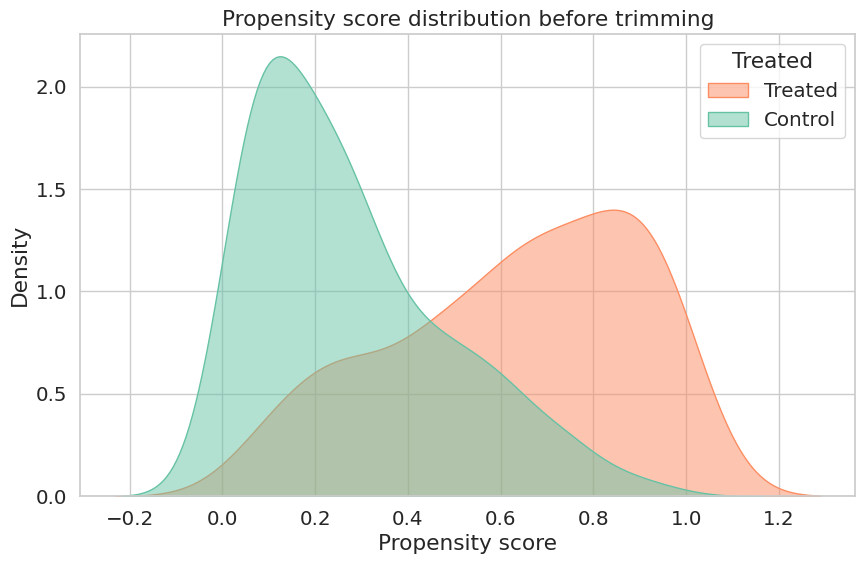


Standardized Mean Differences (before trimming):
gm                        0.1509
opin                      0.6147
opm                       0.2832
roe                       0.2252
stdebt                    0.2335
ind                       0.6883
dirnetwork                0.3097
age                       -0.0004
nquals                    0.4355
boardsize                 0.6945
sector_Basic Materials    -0.0202
sector_Consumer Cyclicals 0.0492
sector_Consumer Non-Cyclicals 0.0897
sector_Energy             -0.1687
sector_Financials         0.0982
sector_Healthcare         -0.1095
sector_Industrials        -0.0168
sector_Technology         0.0270
sector_Telecommunications Services 0.1147
sector_Utilities          -0.1723


In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_final, x='pscore', hue='female', fill=True, common_norm=False, alpha=0.5)
plt.title('Propensity score distribution before trimming')
plt.xlabel('Propensity score')
plt.ylabel('Density')
plt.legend(title='Treated', labels=['Treated', 'Control'])
plt.show()

from sklearn.metrics import mean_squared_error

def smd(col, df):
    m1 = df[df['female']==1][col].mean()
    m0 = df[df['female']==0][col].mean()
    v1 = df[df['female']==1][col].var()
    v0 = df[df['female']==0][col].var()
    return (m1 - m0) / np.sqrt((v1+v0)/2)

print("\nStandardized Mean Differences (before trimming):")
for col in X_vars:
    if col in df_final.columns:
        print(f"{col:25s} {smd(col, df_final):.4f}")

Видим, что распределения находятся далеко друг от друга, что говорит о гетерогенности признаков

**Trimming**

In [ ]:
df_trimmed = df_final[(df_final['pscore'] >= 0.1) & (df_final['pscore'] <= 0.9)].copy()

print("До trimming:", len(df_final))
print("После trimming:", len(df_trimmed))
print("Treated:", (df_trimmed['female'] == 1).sum())
print("Control:", (df_trimmed['female'] == 0).sum())

До trimming: 356
После trimming: 268
Treated: 118
Control: 150


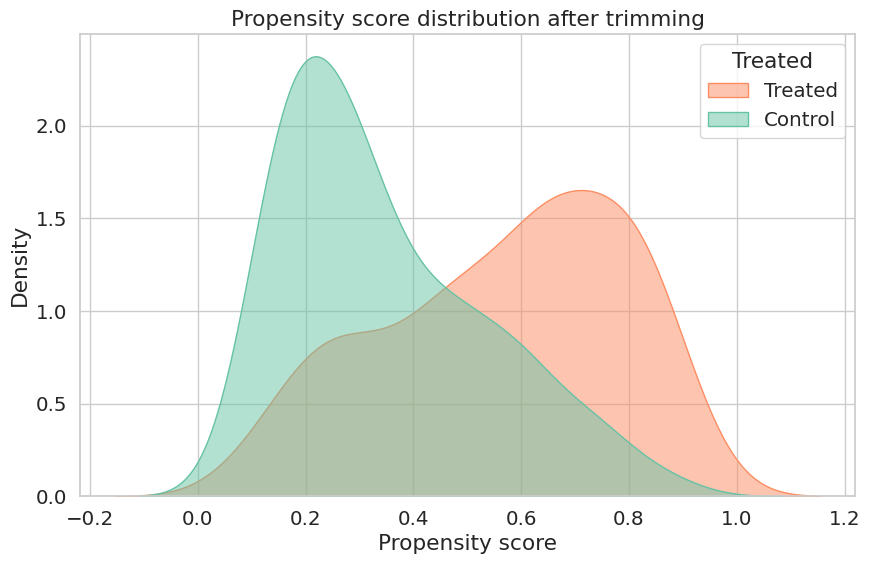


Standardized Mean Differences (before trimming):
gm                        0.1509
opin                      0.6147
opm                       0.2832
roe                       0.2252
stdebt                    0.2335
ind                       0.6883
dirnetwork                0.3097
age                       -0.0004
nquals                    0.4355
boardsize                 0.6945
sector_Basic Materials    -0.0202
sector_Consumer Cyclicals 0.0492
sector_Consumer Non-Cyclicals 0.0897
sector_Energy             -0.1687
sector_Financials         0.0982
sector_Healthcare         -0.1095
sector_Industrials        -0.0168
sector_Technology         0.0270
sector_Telecommunications Services 0.1147
sector_Utilities          -0.1723


In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_trimmed, x='pscore', hue='female', fill=True, common_norm=False, alpha=0.5)
plt.title('Propensity score distribution after trimming')
plt.xlabel('Propensity score')
plt.ylabel('Density')
plt.legend(title='Treated', labels=['Treated', 'Control'])
plt.show()

from sklearn.metrics import mean_squared_error

def smd(col, df):
    m1 = df[df['female']==1][col].mean()
    m0 = df[df['female']==0][col].mean()
    v1 = df[df['female']==1][col].var()
    v0 = df[df['female']==0][col].var()
    return (m1 - m0) / np.sqrt((v1+v0)/2)

print("\nStandardized Mean Differences (before trimming):")
for col in X_vars:
    if col in df_trimmed.columns:
        print(f"{col:25s} {smd(col, df_final):.4f}")

**Propensity Score Matching**

Калипер — максимально допустимая разница в pscore внутри пары. Без калипера всегда будет ближайший сосед и очень далеко может быть. Например, pscore 0.85 у treated и 0.15 у control.

In [ ]:
from sklearn.neighbors import NearestNeighbors

treated_df = df_trimmed[df_trimmed['female'] == 1].copy()
control_df = df_trimmed[df_trimmed['female'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['pscore']].values)
distances, indices = nn.kneighbors(treated_df[['pscore']].values)

caliper = 0.2 * np.std(df_trimmed['pscore'])
valid = distances.flatten() <= caliper

matched_treated = treated_df[valid].copy()
matched_control = control_df.iloc[indices.flatten()[valid]].copy()

print("Матчей:", len(matched_treated))

Матчей: 118


**Stage 2: Supplementary analysis**

In [ ]:
from scipy.stats import ttest_ind

# Плацебо-тест: ROA за 2010
roa_2010 = data[data['year'] == 2010][['id', 'roa']].copy()

matched_treated_y = matched_treated[['id']].merge(roa_2010, on='id', how='inner')
matched_control_y = matched_control[['id']].merge(roa_2010, on='id', how='inner')

placebo_effect = matched_treated_y['roa'].mean() - matched_control_y['roa'].mean()
t_stat, p_val = ttest_ind(matched_treated_y['roa'].dropna(), matched_control_y['roa'].dropna())

print("ROA 2010 среднее Treated:", round(matched_treated_y['roa'].mean(), 6))
print("ROA 2010 среднее Control:", round(matched_control_y['roa'].mean(), 6))
print("Разница:", round(placebo_effect, 6))
print("p-value:", round(p_val, 4))

ROA 2010 среднее Treated: 8.178306
ROA 2010 среднее Control: 7.936069
Разница: 0.242237
p-value: 0.9165


**Тут нулевая гипотеза состоит в том, что средние ROA для treated и control одинаковы. p-value = 0.91 >>> 0.05 => мы не можем отвергнуть нулевую гипотезу => стат значимой разницы между средними нет => мы прошли плацебо-тест**

**Stage 3: Analysis**

In [ ]:
post_years = [2016, 2017, 2018]
roa_post = data[data['year'].isin(post_years)][['id', 'roa']].copy()
roa_post_avg = roa_post.groupby('id')['roa'].mean().reset_index()

treated_post = matched_treated[['id']].merge(roa_post_avg, on='id', how='inner')
control_post = matched_control[['id']].merge(roa_post_avg, on='id', how='inner')

att = treated_post['roa'].mean() - control_post['roa'].mean()

print("ROA_post среднее Treated:", round(treated_post['roa'].mean(), 6))
print("ROA_post среднее Control:", round(control_post['roa'].mean(), 6))
print("ATT:", round(att, 6))

ROA_post среднее Treated: 5.314369
ROA_post среднее Control: 4.176609
ATT: 1.137761


In [ ]:
roa_t = treated_post['roa'].dropna()
roa_c = control_post['roa'].dropna()

t_stat, p_val = ttest_ind(roa_t, roa_c)

print("ROA_post среднее Treated:", round(roa_t.mean(), 6))
print("ROA_post среднее Control:", round(roa_c.mean(), 6))
print("ATT:", round(roa_t.mean() - roa_c.mean(), 6))
print("t-статистика:", round(t_stat, 4))
print("p-value:", round(p_val, 4))

ROA_post среднее Treated: 5.314369
ROA_post среднее Control: 4.176609
ATT: 1.137761
t-статистика: 0.5982
p-value: 0.5503


**Робастность — регрессия с pscore**

In [ ]:
import statsmodels.api as sm

reg_data = pd.concat([
    treated_post.assign(female=1),
    control_post.assign(female=0)
])
reg_data = reg_data.merge(df_trimmed[['id', 'pscore']], on='id', how='left')
reg_data['pscore_sq'] = reg_data['pscore'] ** 2

X_reg = sm.add_constant(reg_data[['female', 'pscore', 'pscore_sq']])
y_reg = reg_data['roa']
model = sm.OLS(y_reg, X_reg).fit()

print(model.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.0243      5.280     -3.224      0.001     -27.428      -6.620
female         1.1291      1.835      0.615      0.539      -2.487       4.745
pscore        76.7433     21.559      3.560      0.000      34.266     119.221
pscore_sq    -60.3779     20.163     -2.995      0.003    -100.103     -20.653


Чувствительность к выбору года (ROA по годам)

In [ ]:
from scipy.stats import ttest_ind

for year in [2016, 2017, 2018]:
    # Берем ROA только за конкретный год
    roa_year = data[data['year'] == year][['id', 'roa']].copy()

    # Объединяем с нашими смэтченными группами
    treated_year = matched_treated[['id']].merge(roa_year, on='id', how='inner').dropna()
    control_year = matched_control[['id']].merge(roa_year, on='id', how='inner').dropna()

    # Считаем ATT и t-тест
    att_year = treated_year['roa'].mean() - control_year['roa'].mean()
    t_stat, p_val = ttest_ind(treated_year['roa'], control_year['roa'])

    print(f"Год: {year}")
    print(f"ROA Treated: {treated_year['roa'].mean():.4f} | ROA Control: {control_year['roa'].mean():.4f}")
    print(f"ATT: {att_year:.4f}")
    print(f"t-статистика: {t_stat:.4f} | p-value: {p_val:.4f}")
    print("-" * 30)

Год: 2016
ROA Treated: 3.7849 | ROA Control: 0.7766
ATT: 3.0083
t-статистика: 1.3583 | p-value: 0.1757
------------------------------
Год: 2017
ROA Treated: 6.7761 | ROA Control: 6.4146
ATT: 0.3615
t-статистика: 0.1549 | p-value: 0.8770
------------------------------
Год: 2018
ROA Treated: 5.3742 | ROA Control: 5.2479
ATT: 0.1264
t-статистика: 0.0710 | p-value: 0.9435
------------------------------


Чувствительность к порогам Trimming

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Задаем разные варианты порогов [нижний, верхний]
trim_thresholds = [(0.1, 0.9), (0.05, 0.95), (0.01, 0.99), (0.0, 1.0)]

for lower, upper in trim_thresholds:
    # 1. Trimming
    df_trim = df_final[(df_final['pscore'] >= lower) & (df_final['pscore'] <= upper)].copy()

    n_treated = (df_trim['female'] == 1).sum()
    n_control = (df_trim['female'] == 0).sum()

    # 2. Matching
    t_df = df_trim[df_trim['female'] == 1].copy()
    c_df = df_trim[df_trim['female'] == 0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(c_df[['pscore']].values)
    distances, indices = nn.kneighbors(t_df[['pscore']].values)

    # Калипер (0.2 стандартных отклонения propensity score в обрезанной выборке)
    caliper = 0.2 * np.std(df_trim['pscore'])
    valid = distances.flatten() <= caliper

    m_treated = t_df[valid].copy()
    m_control = c_df.iloc[indices.flatten()[valid]].copy()

    # 3. Вычисление эффекта (используем твой roa_post_avg за 2016-2018)
    t_post = m_treated[['id']].merge(roa_post_avg, on='id', how='inner').dropna()
    c_post = m_control[['id']].merge(roa_post_avg, on='id', how='inner').dropna()

    if len(t_post) > 0 and len(c_post) > 0:
        att = t_post['roa'].mean() - c_post['roa'].mean()
    else:
        att = np.nan

    print(f"Пороги: [{lower}, {upper}]")
    print(f"  Осталось после тримминга: Treated={n_treated}, Control={n_control}")
    print(f"  Успешных матчей (прошли калипер): {len(m_treated)}")
    print(f"  ATT (2016-2018): {att:.4f}")
    print("-" * 30)

Пороги: [0.1, 0.9]
  Осталось после тримминга: Treated=118, Control=150
  Успешных матчей (прошли калипер): 118
  ATT (2016-2018): 1.1378
------------------------------
Пороги: [0.05, 0.95]
  Осталось после тримминга: Treated=138, Control=183
  Успешных матчей (прошли калипер): 138
  ATT (2016-2018): 0.9843
------------------------------
Пороги: [0.01, 0.99]
  Осталось после тримминга: Treated=147, Control=201
  Успешных матчей (прошли калипер): 147
  ATT (2016-2018): 0.6722
------------------------------
Пороги: [0.0, 1.0]
  Осталось после тримминга: Treated=152, Control=204
  Успешных матчей (прошли калипер): 152
  ATT (2016-2018): 0.6660
------------------------------


In [ ]:
print("=== Проверка баланса (Covariate Balance) ===")

# ДО мэтчинга (но после тримминга)
pscore_t_pre = df_trimmed[df_trimmed['female'] == 1]['pscore'].mean()
pscore_c_pre = df_trimmed[df_trimmed['female'] == 0]['pscore'].mean()

# ПОСЛЕ мэтчинга
pscore_t_post = matched_treated['pscore'].mean()
pscore_c_post = matched_control['pscore'].mean()

print("Средний Propensity Score ДО мэтчинга:")
print(f"  Treated: {pscore_t_pre:.4f} | Control: {pscore_c_pre:.4f}")
print(f"  Разница: {abs(pscore_t_pre - pscore_c_pre):.4f}")

print("\nСредний Propensity Score ПОСЛЕ мэтчинга:")
print(f"  Treated: {pscore_t_post:.4f} | Control: {pscore_c_post:.4f}")
print(f"  Разница: {abs(pscore_t_post - pscore_c_post):.4f}")

=== Проверка баланса (Covariate Balance) ===
Средний Propensity Score ДО мэтчинга:
  Treated: 0.5689 | Control: 0.3464
  Разница: 0.2225

Средний Propensity Score ПОСЛЕ мэтчинга:
  Treated: 0.5689 | Control: 0.5688
  Разница: 0.0000


Разница до мэтчинга - 0.22, а после мэтчинга ~ 0 . Это доказательство того, что мэтчинг сработал корректно.